# Análise Portal da Transparência

Este notebook lê a camada SILVER (Já limpa e tipada) e responde as perguntas de negócio apioado por métricas e gráficos para uma melhor tomada de decisão.
os dados são extraídos da base de viagens a Serviços do portal de Transparência do Governo Federal.

As perguntas de negócio a serem respondidas serão:
- Os 5 órgãos com maior custo total? 
- Os 3 destinos com maior custo médio por viagem? 
- A viagem de maior duração e seu custo total? 
- Qual o tipo de pagamento com maior valor médio? 
- Qual o meio de transporte mais usado nos trechos? 
- Qual UF de destino aparece em mais trechos? 
- Qual órgão pagou mais no total? 

Além disso, respode também três perguntas de negócio extra, sugeridos após análise do banco de dados e nas perguntas anteriores:
- Qual o custo total de viagens por meio de transporte e situação do pedido?
- Qual o gasto em passagens de acordo com a urgência da viagem?
- Qual é a evolução mensal dos gastos com viagens?

# Conexão com o Banco de Dados


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

import script.banco as banco  

conexao = banco.conectar()

def consultar(sql):
    """Roda um SELECT e devolve o resultado como DataFrame do pandas."""
    return pd.read_sql(sql, conexao)


def reais(valor):
    """Formata um numero como moeda brasileira: 1234.5 -> 'R$ 1.234,50'."""
    texto = f'{valor:,.2f}'
    return 'R$ ' + texto.replace(',', 'X').replace('.', ',').replace('X', '.')

print('Conectado ao MySQL com sucesso.')

Conectado ao MySQL com sucesso.


# Perguntas de negócio 



## Pergunta 1: Os 5 órgãos com maior custo total? 

In [17]:
# Query para agrupar os custos por órgão pagador e filtrar os 5 maiores
query_top_orgaos = """
SELECT 
    nome_orgao_pagador AS orgao,
    SUM(valor) AS custo_total
FROM silver_pagamento
GROUP BY nome_orgao_pagador
ORDER BY custo_total DESC
LIMIT 5;
"""

df_top_orgaos = consultar(query_top_orgaos)

# Tratando coluna de moeda
df_top_orgaos['custo_total_formatado'] = df_top_orgaos['custo_total'].apply(reais)

# Exibindo o DataFrame resultante

print('\n--- 5 Orgãos com maior gasto total ---')
display(df_top_orgaos)

/tmp/ipykernel_1231/714574229.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)



--- 5 Orgãos com maior gasto total ---


,orgao,custo_total,custo_total_formatado
0,Fundo Nacional de Segurança Pública,2.784810e+08,"R$ 278.481.047,89"
1,Sigiloso,2.004848e+08,"R$ 200.484.801,68"
2,Comando da Aeronáutica,8.176914e+07,"R$ 81.769.144,77"
3,Instituto Nacional do Seguro Social,3.742760e+07,"R$ 37.427.601,45"
4,Comando do Exército,3.687264e+07,"R$ 36.872.643,95"


Criação do gráfico:

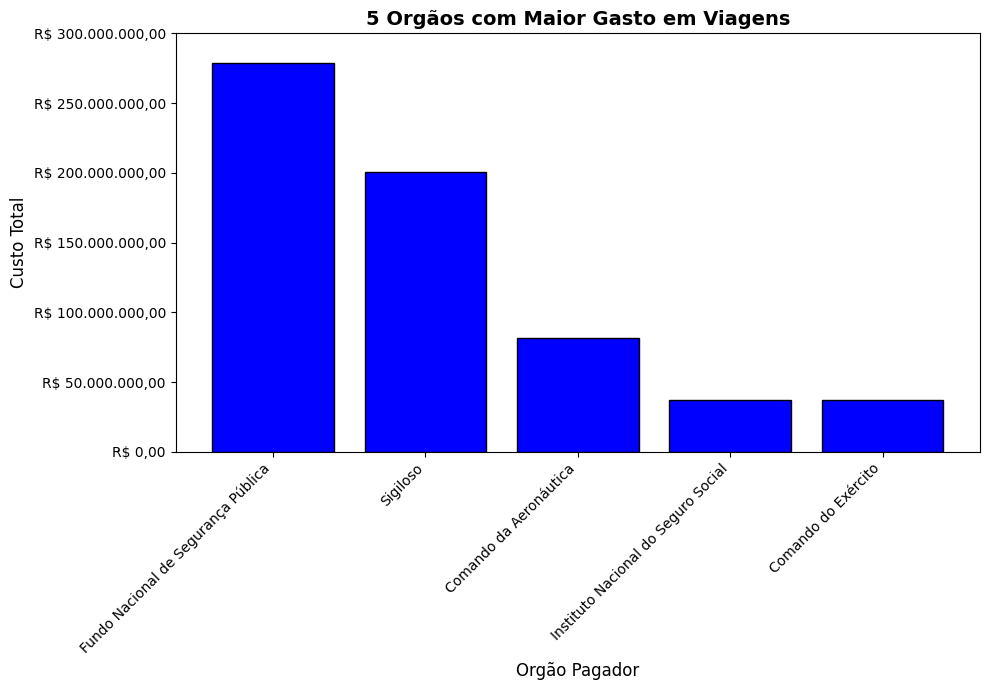

In [18]:
fig, ax = plt.subplots(figsize=(10, 7))

# Barras Verticais
ax.bar(df_top_orgaos['orgao'], df_top_orgaos['custo_total'], color='blue', edgecolor='black')
valores_eixo_y = ax.get_yticks()

# Formatar texto
valores_formatados = [reais(v) for v in valores_eixo_y]

# Forçamos o Matplotlib a usar as mesmas posições, mas mudando o texto
ax.set_yticks(valores_eixo_y)
ax.set_yticklabels(valores_formatados)


plt.title('5 Orgãos com Maior Gasto em Viagens', fontsize=14, fontweight='bold')
plt.xlabel('Orgão Pagador', fontsize=12)
plt.ylabel('Custo Total', fontsize=12)

# Rotação para evitar sobreposição
plt.xticks(rotation=45, ha='right', fontsize=10)

#Exibe
plt.tight_layout()
plt.show()

Como vemos na tabela, temos um número enorme de viagens onde o orgão não é mencionado, talvez por uma questão legal.  Além disso, os dois primeiros colocados somam mais do que os outros três juntos. Isso indica forte concentração de gasto em poucos órgãos.

## Pergunta 2 - Os 3 destinos com maior custo médio por viagem? 



In [52]:
# Query calculando a média do valor_total agrupado por destinos
query_top_destinos = """
SELECT 
    destinos AS destino, 
    AVG(valor_total) AS custo_medio 
FROM silver_viagem 
GROUP BY destinos 
ORDER BY custo_medio DESC 
LIMIT 3;
"""

# Executa a consulta
df_top_destinos = consultar(query_top_destinos)

# Formata os valores 
df_top_destinos['custo_medio_formatado'] = df_top_destinos['custo_medio'].apply(reais)

# Exibe
display(df_top_destinos[['destino', 'custo_medio_formatado']])

/tmp/ipykernel_1231/714574229.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,destino,custo_medio_formatado
0,"Abu Dabi/Emirados Árabes, Riad/Arábia Saudita,...","R$ 245.852,80"
1,"Brasília/DF, Rio Branco/AC, Cruzeiro do Sul/AC...","R$ 216.729,36"
2,"Brasília/DF, Rio de Janeiro/RJ, Angra dos Reis...","R$ 207.220,14"


Aparentemente os dados são inseridos levando em consideração todo o itinerário de cada viagem na coluna `destino`. 

Na tabela `silver_trecho` essa informação está individualizada, então usaremos um INNER JOIN para listar cada destino de forma separada

In [56]:
# Query associando trecho e viagem 
query_top_destinos = """
SELECT 
    t.destino_cidade AS destino, 
    AVG(v.valor_total) AS custo_medio 
FROM silver_viagem v
INNER JOIN silver_trecho t ON v.id_viagem = t.id_viagem
GROUP BY t.destino_cidade 
ORDER BY custo_medio DESC 
LIMIT 3;
"""

# Executa a consulta no banco
df_top_destinos = consultar(query_top_destinos)

# Formata os valores
df_top_destinos['custo_medio_formatado'] = df_top_destinos['custo_medio'].apply(reais)

# Exibe os resultados 
display(df_top_destinos[['destino', 'custo_medio_formatado']])

/tmp/ipykernel_1231/714574229.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,destino,custo_medio_formatado
0,Tejupá,"R$ 115.175,00"
1,Chavantes,"R$ 114.557,01"
2,Teolândia,"R$ 109.322,50"


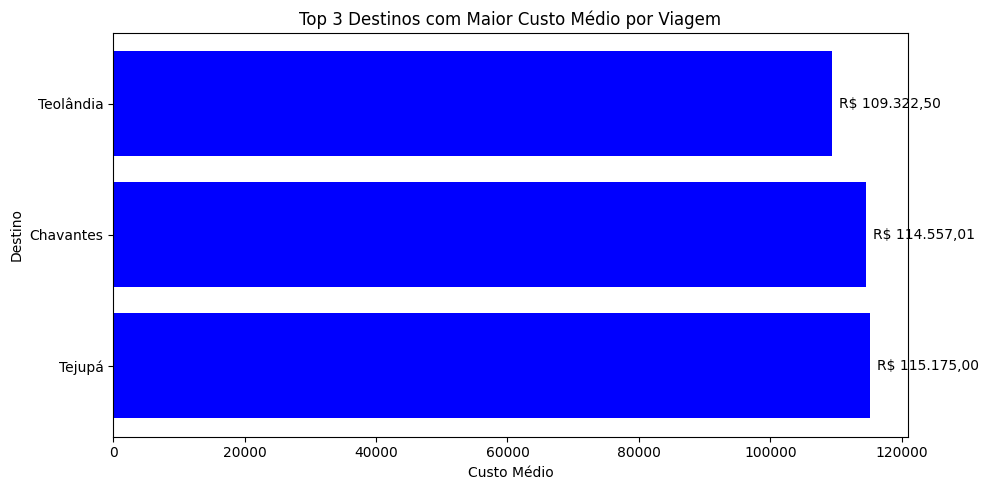

In [57]:
plt.figure(figsize=(10, 5))

# Barras Horizontais
barras = plt.barh(df_top_destinos['destino'], df_top_destinos['custo_medio'], color='blue')

# Adiciona os rótulos 
plt.title('Top 3 Destinos com Maior Custo Médio por Viagem')
plt.xlabel('Custo Médio')
plt.ylabel('Destino')

plt.bar_label(barras, labels=df_top_destinos['custo_medio_formatado'], padding=5)

# Exibe
plt.tight_layout()
plt.show()

## Pergunta 3 - A viagem de maior duração e seu custo total? 

In [67]:
# Query buscando a viagem com a maior duração
query_maior_duracao = """
SELECT 
    id_viagem,
    nome_viajante,
    destinos AS destino,
    duracao_dias,
    valor_total AS custo_total
FROM silver_viagem
ORDER BY duracao_dias DESC
LIMIT 1;
"""

# Executa a consulta no banco
df_maior_duracao = consultar(query_maior_duracao)

# Formata o custo total
df_maior_duracao['custo_total_formatado'] = df_maior_duracao['custo_total'].apply(reais)

# Exibe o resultado
display(df_maior_duracao[['id_viagem', 'nome_viajante', 'destino', 'duracao_dias', 'custo_total_formatado']])

/tmp/ipykernel_1231/714574229.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,id_viagem,nome_viajante,destino,duracao_dias,custo_total_formatado
0,0000000000020699856,LUISANGELA CORREA FRANCO DE FARIA,Mogi Mirim/SP,383,"R$ 0,00"


Como o custo_total retornou zerado, vou confirmar trazendo todas as informações sobre a viagem para uma melhor análise.

In [68]:
query_p3 = """
SELECT 
    id_viagem,
    nome_viajante,
    nome_orgao_superior,
    periodo_data_inicio,
    periodo_data_fim,
    duracao_dias,
    valor_diarias,
    valor_passagens,
    valor_outros_gastos,
    valor_devolucao,
    valor_total AS custo_total
FROM silver_viagem
ORDER BY duracao_dias DESC
LIMIT 1;
"""

# Executa a consulta e armazena no DataFrame
df_p3 = pd.read_sql_query(query_p3, conexao)


# Exibe o resultado na tela
df_p3

/tmp/ipykernel_1231/3883545641.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_p3 = pd.read_sql_query(query_p3, conexao)


,id_viagem,nome_viajante,nome_orgao_superior,periodo_data_inicio,periodo_data_fim,duracao_dias,valor_diarias,valor_passagens,valor_outros_gastos,valor_devolucao,custo_total
0,0000000000020699856,LUISANGELA CORREA FRANCO DE FARIA,Ministério da Previdência Social,2025-01-13,2026-01-31,383,0.0,0.0,0.0,0.0,0.0


As informações completas da viagem nos mostra que não foram inseridos dados nos custos da viagem, o que explica estar zerado. A quantidade de dias pode indicar desde uma anomalia ou até mesmo uma viagem missionária, a trabalho, mudança, etc. 

## Pergunta 4 - Qual o tipo de pagamento com maior valor médio? 

In [73]:
# Query para calcular o valor médio agrupado por tipo de pagamento
query_tipo_pagamento = """
SELECT 
    tipo_pagamento, 
    AVG(valor) AS valor_medio
FROM silver_pagamento
GROUP BY tipo_pagamento
ORDER BY valor_medio DESC;
"""

# Executa a consulta
df_pagamento = consultar(query_tipo_pagamento)

# Formata o valor
df_pagamento['valor_medio_formatado'] = df_pagamento['valor_medio'].apply(reais)

# Exibe o resultado 
display(df_pagamento[['tipo_pagamento', 'valor_medio_formatado']])

/tmp/ipykernel_1231/714574229.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,tipo_pagamento,valor_medio_formatado
0,DIÁRIAS,"R$ 2.078,28"
1,PASSAGEM,"R$ 1.878,34"
2,Serviço correlato: seguro,"R$ 447,51"
3,RESTITUIÇÃO,"R$ 245,70"


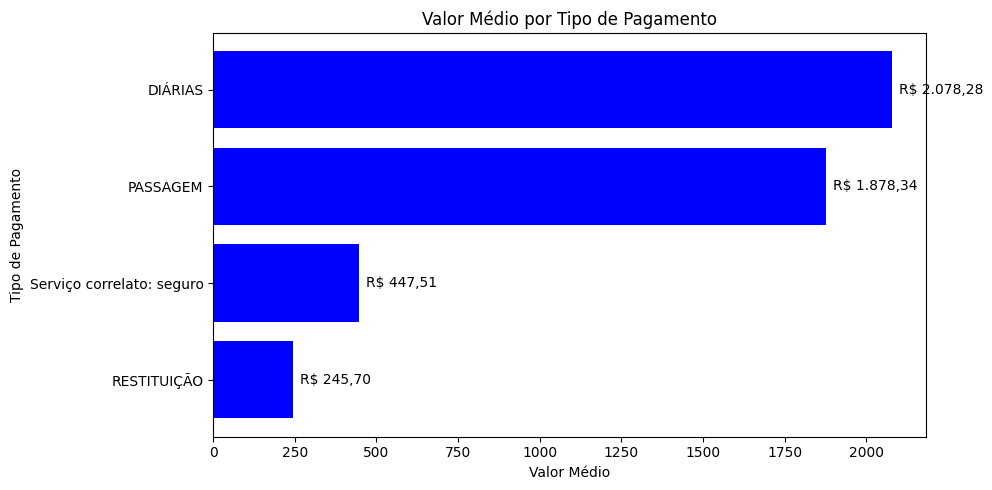

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Barras Horizontais
barras = plt.barh(df_pagamento['tipo_pagamento'], df_pagamento['valor_medio'], color='blue')

# Adiciona os rótulos 
plt.title('Valor Médio por Tipo de Pagamento')
plt.xlabel('Valor Médio')
plt.ylabel('Tipo de Pagamento')

plt.bar_label(barras, labels=df_pagamento['valor_medio_formatado'], padding=5)

# Maior valor no topo
plt.gca().invert_yaxis()

# Exibe
plt.tight_layout()
plt.show()

Os pagamentos com `diárias` e `passagens` por motivos óbvios acabam sendo os maiores na média.

## Pergunta 5 - Qual o meio de transporte mais usado nos trechos? 

In [77]:
# Query para contar a quantidade de trechos por meio de transporte
query_meio_transporte = """
SELECT 
    meio_transporte, 
    COUNT(*) AS quantidade
FROM silver_trecho
GROUP BY meio_transporte
ORDER BY quantidade DESC;
"""

# Executa a consulta no banco
df_transporte = consultar(query_meio_transporte)

# Exibe o resultado
display(df_transporte)

/tmp/ipykernel_1231/714574229.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,meio_transporte,quantidade
0,Veículo Oficial,386424
1,Aéreo,232666
2,Rodoviário,64970
3,Veículo Próprio,42846
4,Inválido,26659
5,Fluvial,8429
6,Ferroviário,874
7,Marítimo,481


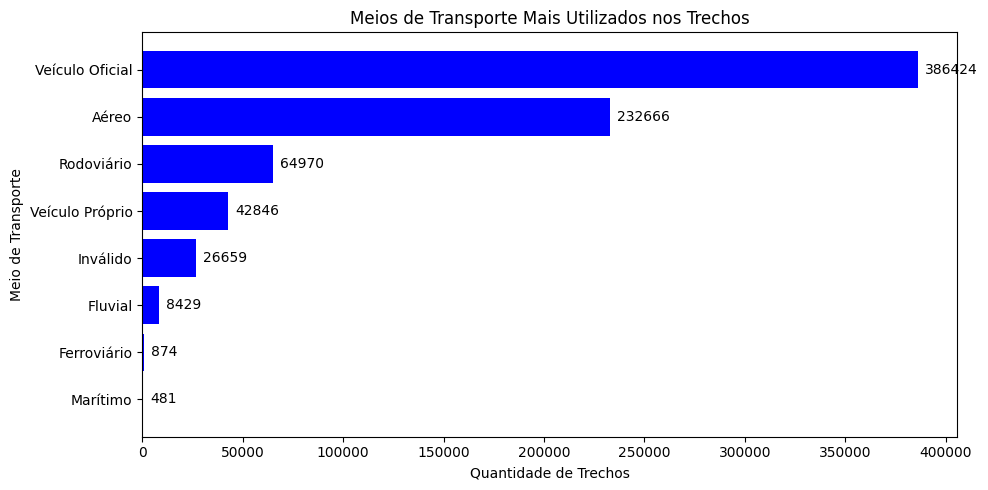

In [26]:
plt.figure(figsize=(10, 5))

# Barras Horizontais
barras = plt.barh(df_transporte['meio_transporte'], df_transporte['quantidade'], color='blue')

# Adiciona os rótulos 
plt.title('Meios de Transporte Mais Utilizados nos Trechos')
plt.xlabel('Quantidade de Trechos')
plt.ylabel('Meio de Transporte')

plt.bar_label(barras, labels=df_transporte['quantidade'], padding=5)

# Maior valor no topo
plt.gca().invert_yaxis()

# Exibe
plt.tight_layout()
plt.show()

Mais da metade dos transportes usados nos trechos é o `Veículo Oficial`, seguido do `Aéreo`. Isso evidencia a dependência da frota do Governo Federal e de meios mais caros, o que torna o custo total das viagens maior. Se somarmos, os deslocamentos terrestres ainda são a maioria.

## Pergunta 6 - Qual UF de destino aparece em mais trechos? 

In [83]:
# Query para contar a quantidade de trechos por UF ignorando valores nulos
query_uf_destino = """
SELECT 
    destino_uf AS uf, 
    COUNT(*) AS quantidade
FROM silver_trecho
WHERE destino_uf IS NOT NULL AND destino_uf != ''
GROUP BY destino_uf
ORDER BY quantidade DESC
LIMIT 10;
"""

# Executa a consulta no banco
df_uf = consultar(query_uf_destino)

# Exibe a tabela
print('Top 10 UFs que aparece em mais trechos')
display(df_uf)

/tmp/ipykernel_1231/714574229.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


Top 10 UFs que aparece em mais trechos


,uf,quantidade
0,São Paulo,82722
1,Distrito Federal,79962
2,Minas Gerais,50965
3,Rio de Janeiro,44197
4,Paraná,42603
5,Pará,40044
6,Rio Grande do Sul,38684
7,Mato Grosso do Sul,30516
8,Bahia,28375
9,Pernambuco,28372


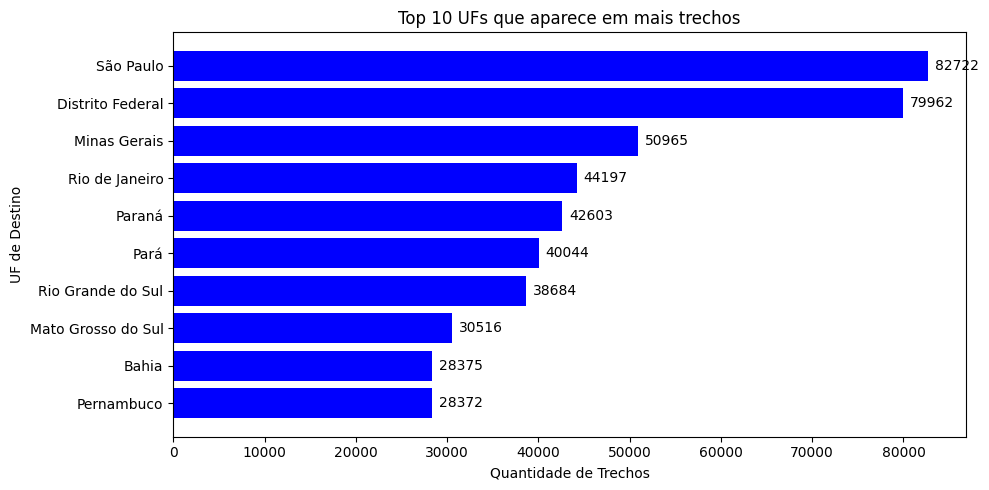

In [28]:
plt.figure(figsize=(10, 5))

# Barras Horizontais
barras = plt.barh(df_uf['uf'], df_uf['quantidade'], color='blue')

# Adiciona os rótulos 
plt.title('Top 10 UFs que aparece em mais trechos')
plt.xlabel('Quantidade de Trechos')
plt.ylabel('UF de Destino')

plt.bar_label(barras, labels=df_uf['quantidade'], padding=5)

# Maior valor no topo
plt.gca().invert_yaxis()

# Exibe
plt.tight_layout()
plt.show()

De acordo com os dados, a cidade de São Paulo é a que mais aparece em trechos. A capital vem logo em seguida.

## Pergunta 7 - Qual órgão pagou mais no total? 

In [84]:
# Query para calcular o valor total gasto agrupado por órgão pagador (Top 5)
query_orgao_pagador = """
SELECT 
    nome_orgao_pagador AS orgao, 
    SUM(valor) AS valor_total
FROM silver_pagamento
WHERE nome_orgao_pagador IS NOT NULL AND nome_orgao_pagador != ''
GROUP BY nome_orgao_pagador
ORDER BY valor_total DESC
LIMIT 10;
"""

# Executa a consulta no banco
df_orgao = consultar(query_orgao_pagador)

# Formata o valor 
df_orgao['valor_total_formatado'] = df_orgao['valor_total'].apply(reais)

# Exibe 
display(df_orgao[['orgao', 'valor_total_formatado']])

/tmp/ipykernel_1231/714574229.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,orgao,valor_total_formatado
0,Fundo Nacional de Segurança Pública,"R$ 278.481.047,89"
1,Sigiloso,"R$ 200.484.801,68"
2,Comando da Aeronáutica,"R$ 81.769.144,77"
3,Instituto Nacional do Seguro Social,"R$ 37.427.601,45"
4,Comando do Exército,"R$ 36.872.643,95"
5,Ministério da Gestão e da Inovação em Serviços...,"R$ 35.541.760,71"
6,Instituto Brasileiro do Meio Ambiente e dos Re...,"R$ 31.589.853,15"
7,Ministério das Relações Exteriores - Unidades ...,"R$ 25.605.376,38"
8,Receita Federal do Brasil,"R$ 23.811.027,00"
9,Ministério da Agricultura e Pecuária - Unidade...,"R$ 22.899.880,25"


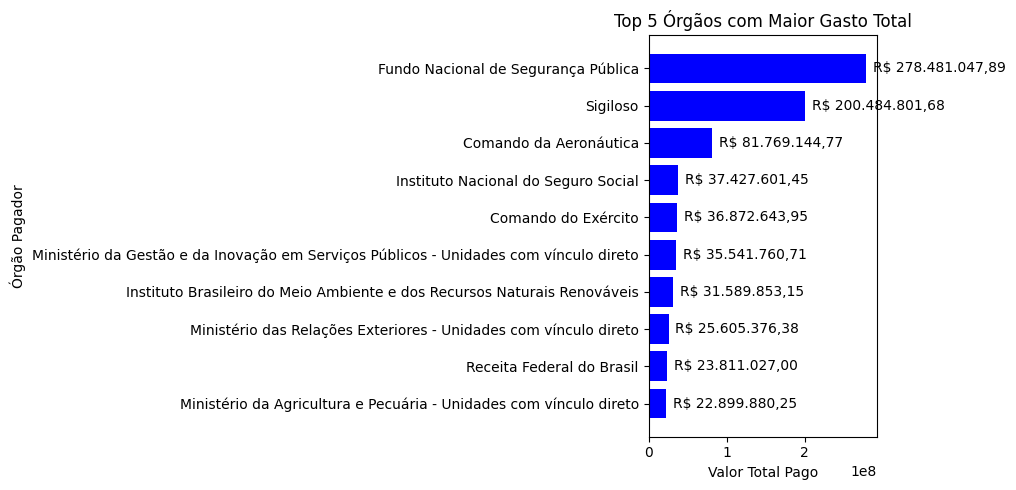

In [30]:
plt.figure(figsize=(10, 5))

# Barras Horizontais para o Top 5 órgãos que mais pagaram
barras = plt.barh(df_orgao['orgao'], df_orgao['valor_total'], color='blue')

# Adiciona os rótulos 
plt.title('Top 5 Órgãos com Maior Gasto Total')
plt.xlabel('Valor Total Pago')
plt.ylabel('Órgão Pagador')

plt.bar_label(barras, labels=df_orgao['valor_total_formatado'], padding=5)

# Inverte o eixo vertical para colocar o maior gasto no topo
plt.gca().invert_yaxis()

# Exibe
plt.tight_layout()
plt.show()

# Camada GOLD Agregada (agg)

In [31]:
banco.executar(conexao, "DROP TABLE IF EXISTS gold_gasto_orgao_modal;")

sql_gold_tabela = """
CREATE TABLE gold_gasto_orgao_modal AS
SELECT 
    v.nome_orgao_superior AS orgao,
    t.meio_transporte AS modal,
    COUNT(DISTINCT v.id_viagem) AS qtd_viagens,
    SUM(v.valor_total) AS custo_total
FROM silver_viagem v
JOIN silver_trecho t ON v.id_viagem = t.id_viagem
GROUP BY v.nome_orgao_superior, t.meio_transporte;
"""
banco.executar(conexao, sql_gold_tabela)
print("Tabela gold_gasto_orgao_modal criada.")

sql_gold_view = """
CREATE OR REPLACE VIEW vw_gold_gasto_orgao_modal AS
SELECT orgao, modal, qtd_viagens, custo_total
FROM gold_gasto_orgao_modal;
"""
banco.executar(conexao, sql_gold_view)
print("View vw_gold_gasto_orgao_modal criada.")

Tabela gold_gasto_orgao_modal criada.
View vw_gold_gasto_orgao_modal criada.


## Pergunta Extra 1: Qual o custo total de viagens por meio de transporte e situação do pedido?

Vamos analisar o custo por tipo de meio de transporte e de acordo com a situação da viagem, se foi ou não cancelada.

In [32]:
query_extra_1 = """
SELECT 
    t.meio_transporte AS modal,
    v.situacao AS situacao_viagem,
    SUM(v.valor_total) AS custo_total
FROM silver_viagem v
INNER JOIN silver_trecho t ON TRIM(v.id_viagem) = TRIM(t.id_viagem)
GROUP BY t.meio_transporte, v.situacao
ORDER BY custo_total DESC
LIMIT 5;
"""

df_extra_1 = consultar(query_extra_1)

# Exibe
df_exibicao_1 = df_extra_1.copy()
df_exibicao_1['custo_total'] = df_exibicao_1['custo_total'].apply(reais)
display(df_exibicao_1)

/tmp/ipykernel_1231/714574229.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,modal,situacao_viagem,custo_total
0,Veículo Oficial,Realizada,"R$ 2.819.277.391,31"
1,Aéreo,Realizada,"R$ 1.489.587.609,50"
2,Veículo Próprio,Realizada,"R$ 885.318.927,14"
3,Rodoviário,Realizada,"R$ 457.138.531,18"
4,Inválido,Realizada,"R$ 277.702.111,90"


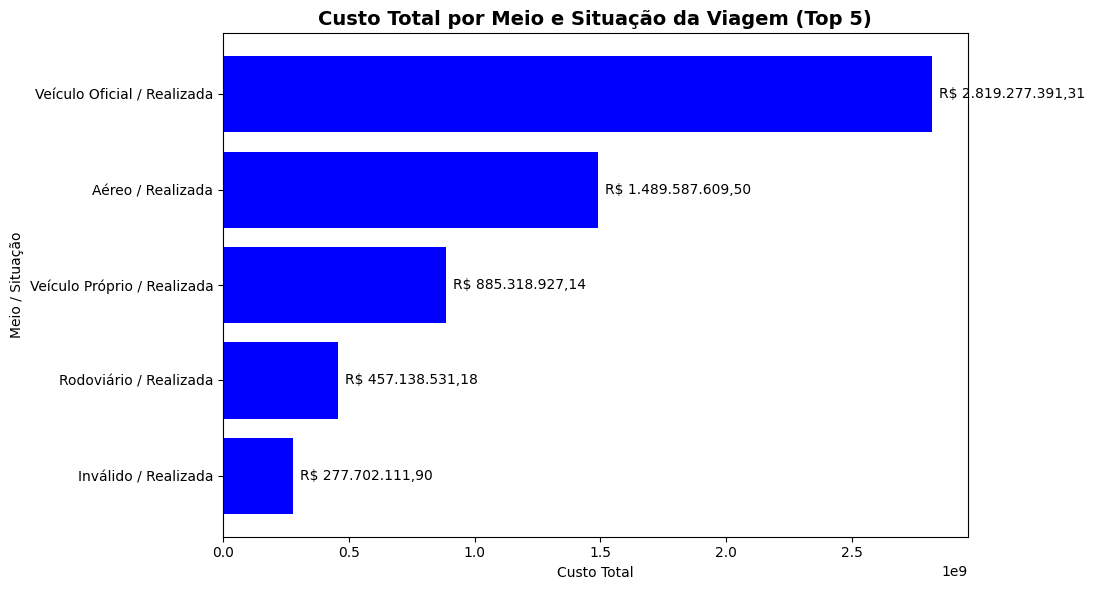

In [33]:
fig, ax = plt.subplots(figsize=(11, 6))

labels = df_extra_1['modal'] + ' / ' + df_extra_1['situacao_viagem']
barras = ax.barh(labels, df_extra_1['custo_total'], color='blue')

ax.bar_label(barras, labels=df_extra_1['custo_total'].apply(reais), padding=5)
ax.set_title('Custo Total por Meio e Situação da Viagem (Top 5)', fontsize=14, fontweight='bold')
ax.set_xlabel('Custo Total')
ax.set_ylabel('Meio / Situação')

# Maior valor no topo
plt.gca().invert_yaxis()

# Exibe
plt.tight_layout()
plt.show()

## Pergunta Extra 2: Qual o gasto em passagens de acordo com a urgência da viagem?

In [34]:
query_extra_2 = """
SELECT 
    v.viagem_urgente AS urgente,
    SUM(p.valor_passagem) AS total_passagens
FROM silver_viagem v
INNER JOIN silver_passagem p ON TRIM(v.id_viagem) = TRIM(p.id_viagem)
GROUP BY v.viagem_urgente
ORDER BY total_passagens DESC
"""
df_extra_2 = consultar(query_extra_2)

# Criamos uma cópia temporária apenas para exibir
df_exibicao_2 = df_extra_2.copy()
df_exibicao_2['total_passagens'] = df_exibicao_2['total_passagens'].apply(reais)
df_exibicao_2

/tmp/ipykernel_1231/714574229.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,urgente,total_passagens
0,SIM,"R$ 223.316.841,85"
1,NÃO,"R$ 94.421.184,59"


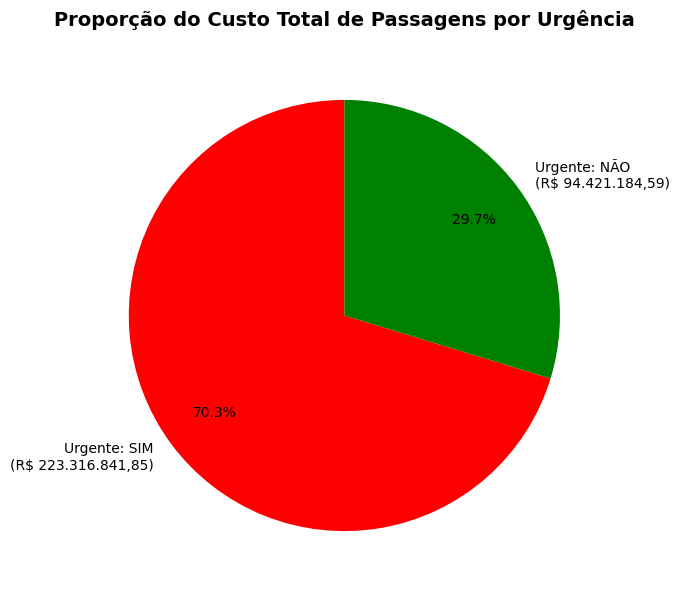

In [35]:
fig, ax = plt.subplots(figsize=(7, 7))

# Cria os rótulos 
labels_simplificadas = "Urgente: " + df_extra_2['urgente'] + "\n(" + df_extra_2['total_passagens'].apply(reais) + ")"

# Pizza
ax.pie(
    df_extra_2['total_passagens'], 
    labels=labels_simplificadas, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['red', 'green'],
    pctdistance=0.75
)

# Exibe
ax.set_title('Proporção do Custo Total de Passagens por Urgência', fontsize=14, fontweight='bold', pad=15)
plt.show()

Tanto na tabela 

## Pergunta Extra 3: Qual é a evolução mensal dos gastos com viagens?


In [36]:
query_extra_3 = """
SELECT 
    LEFT(CAST(t.origem_data AS CHAR(10)), 7) AS mes_ano,
    SUM(p.valor_passagem) AS total_passagens
FROM silver_passagem p
INNER JOIN silver_trecho t ON TRIM(p.id_viagem) = TRIM(t.id_viagem)
WHERE t.origem_data IS NOT NULL
GROUP BY LEFT(CAST(t.origem_data AS CHAR(10)), 7)
ORDER BY mes_ano ASC
LIMIT 12;
"""
df_extra_3 = consultar(query_extra_3)

# Exibe
df_exibicao_3 = df_extra_3.copy()
df_exibicao_3['total_passagens'] = df_exibicao_3['total_passagens'].astype(object).apply(reais)
df_exibicao_3

/tmp/ipykernel_1231/714574229.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,mes_ano,total_passagens
0,2025-01,"R$ 62.915.622,05"
1,2025-02,"R$ 111.329.272,60"
2,2025-03,"R$ 155.562.874,79"
3,2025-04,"R$ 149.648.743,49"
4,2025-05,"R$ 191.416.052,49"
5,2025-06,"R$ 185.823.560,79"
6,2025-07,"R$ 28.253.922,80"
7,2025-08,"R$ 11.440.731,83"
8,2025-09,"R$ 8.017.660,31"
9,2025-10,"R$ 8.472.762,18"


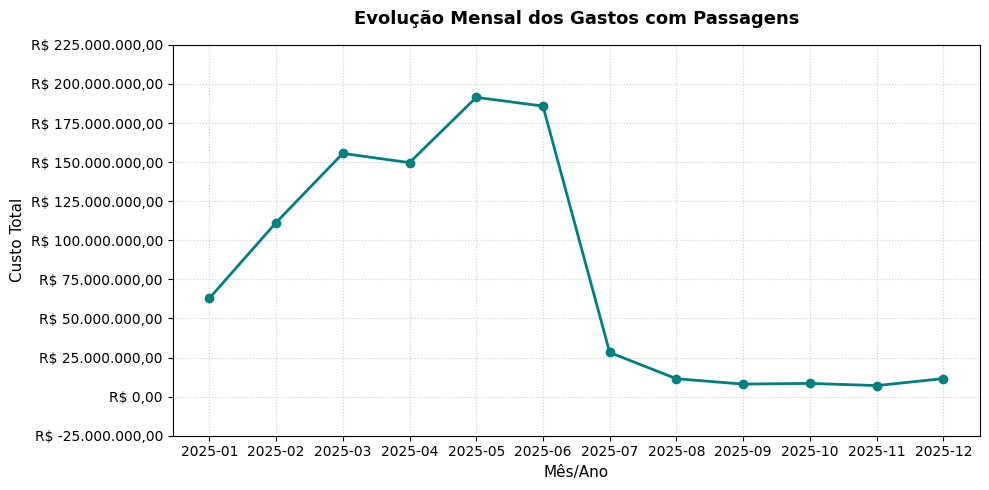

In [37]:
fig, ax = plt.subplots(figsize=(10, 5))

# Linha temporal
ax.plot(df_extra_3.iloc[:, 0], df_extra_3.iloc[:, 1], marker='o', color='teal', linewidth=2)

ax.set_title('Evolução Mensal dos Gastos com Passagens', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Mês/Ano', fontsize=11)
ax.set_ylabel('Custo Total', fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6)

# Formatação da moeda 
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([reais(v) for v in ax.get_yticks()])

#Exibe
plt.tight_layout()
plt.show()